#ECE 570 Final Project Notebook
Prithvi Dhanabal

# Imports

In [1]:
#All imports needed are below
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import numpy as np
import time
import matplotlib.pyplot as plt
import psutil, os
import torch.nn.functional as F
!pip install torchattacks
import torchattacks
import copy
from statistics import mean
#Check that running on GPU is possible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
#Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
  Attempting uninstall: chardet
    Found existing installation: chardet 5.2.0
    Uninstalling chardet-5.2.0:
      Successfully uninstalled chardet-5.2.0
  Attempting uninstall: requests
    Found existing installation: req

# Key Experiment-Specific Functions

In [2]:
#Corrupt Data (key function)
def corrupt_labels(dataset, corruption_rate=0.2):
  #Total size of dataset and corruption size
  n = len(dataset.targets)
  to_corrupt = int(n * corruption_rate)
  #Select indices to corrupt randomly
  corrupt_indices = np.random.choice(n,to_corrupt,replace=False)
  #Shallow copy for comparison later
  before_targets = dataset.targets.clone()
  #Loop through each index and set the label randomly (can end up as same)
  for i in corrupt_indices:
    #ASSUMES FASHIONMNIST: Max classification label is 9
    dataset.targets[i] = np.random.randint(10)

  #(For tracking purposes only) Get true corruption count
  non_corrupt = torch.eq(before_targets, dataset.targets).sum().item()
  #Convert to a rate for comparison since that is the function input
  actual_corrupt_rate = (1 - non_corrupt/n)

  return dataset, actual_corrupt_rate

#Mixup Data (key function)
def mixup_data(X, y, alpha=0.25):
  #Size of training data
  n = X.shape[0]

  lam = 1.0 #Default value in case alpha <= 0
  if (alpha > 0):
    lam = np.random.beta(alpha, alpha)

  #Generate the "j" indices for x_hat = l*x_i + (1-l)*x_j
  second_index = np.random.permutation(n)

  #Generate X_mixup and soft y_mixup
  X_mixup = lam*X + (1-lam)*X[second_index,:]
  y_i, y_j = y, y[second_index]

  return X_mixup, y_i, y_j, lam

#Calculate loss using CE loss function, incorporate y augmentation
def mixup_f(loss_func, f, y_i, y_j, lam):
  out = lam * loss_func(f, y_i) + (1-lam) * loss_func(f, y_j)
  return out

# Get Datasets

In [3]:
#Constants
b_size = 1024 #From original project

#Transformation for Fashion-MNIST set
transform_fashion = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))
    ])
#Get datasets. Ensure download if not there already
train_in = datasets.FashionMNIST(root='~/FaMNIST', train=True, download=True, transform=transform_fashion)
test_in = datasets.FashionMNIST(root='~/FaMNIST', train=False, download=True, transform=transform_fashion)
#Shuffle indices and generate batches
train_batch = torch.utils.data.DataLoader(train_in, batch_size=b_size, shuffle=True)
test_batch = torch.utils.data.DataLoader(test_in, batch_size=b_size)

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 266kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 44.4MB/s]


# Define NN

In [4]:
#Simple CNN: 2 Conv Layers, 3 FC layers
class net(nn.Module):
  def __init__(self):
    super(net, self).__init__()
    #Define two conv layers
    #Conv1: known 1 in_channels for FMNIST data
    self.conv1 = nn.Conv2d(1, 32, 3, 1)
    #Conv2: known 32 in_channels from Conv1 output
    self.conv2 = nn.Conv2d(32, 64, 3, 1)
    #FC1 input shape from output shape of Conv2
    self.fc1 = nn.Linear(1600,512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10)
  def forward(self, x):
    #Apply Conv layers
    x = F.relu(F.max_pool2d(self.conv1(x), 2))
    x = F.relu(F.max_pool2d(self.conv2(x), 2))
    #Flatten
    x = x.view(-1, 1600)
    #Apply FC layers. DO NOT ACTIVATE OTUPUT LAYER, DONE IN CE LOSS
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return self.fc3(x)

# Train & Test Functions: Mixup

In [5]:
#Adapted from HW2 train/test functions
def train_mixup(alpha, model, loss_func, optim_func, train_batch):
  model.train() #Switch to training mode
  train_loss = 0
  correct = 0
  total = 0
  #Loop through batches
  for batch_i, (x, y) in enumerate(train_batch):
    x = x.to(device)
    y = y.to(device)
    #Get the mixup x and y components
    x_hat, y_i, y_j, lam = mixup_data(x, y, alpha)

    #Compute value of prediction and loss using mixup data
    f = model(x_hat)
    loss = mixup_f(loss_func, f, y_i, y_j, lam)

    #Compute loss: adapted from HW2
    train_loss += loss.item()
    predicted = f.argmax(dim=1)
    total += y.size(0)
    correct += (
    lam * predicted.eq(y_i.data).sum().item()
    + (1 - lam) * predicted.eq(y_j.data).sum().item())

    optim_func.zero_grad()
    loss.backward()
    optim_func.step()
  batch_count = batch_i + 1
  #Return avg loss and accuracy
  return (train_loss/batch_count, 100.*correct/total)

def test_mixup(model, loss_func, test_batch, adv=False, attack=None):
  model.eval()
  test_loss = 0
  correct = 0
  total = 0
  #Loop through batches
  for batch_idx, (x, y) in enumerate(test_batch):
    x = x.to(device)
    y = y.to(device)
    x_used = x
    #Use FGSM attack if flagged
    if (adv==True):
      x_used = attack(x,y)
    #Test and record accuracy
    with torch.no_grad():
      f = model(x_used)
      loss = loss_func(f, y)
      test_loss += loss.item()
      _, predicted = torch.max(f.data, 1)
    total += y.size(0)
    correct += predicted.eq(y.data).cpu().sum().item()
  batch_count = batch_idx + 1
  #Return avg loss and accuracy
  return (test_loss/batch_count, 100.*correct/total)

# Train & Test Functions: Standard

In [6]:
#Adapted from HW2 train/test functions
def train(model, loss_func, optim_func, train_batch):
  model.train() #Switch to training mode
  train_loss = 0
  correct = 0
  total = 0
  for batch_i, (x, y) in enumerate(train_batch):
    x = x.to(device)
    y = y.to(device)

    #Compute value of prediction and loss
    f = model(x)
    loss = loss_func(f, y)

    train_loss += loss.item()
    predicted = f.argmax(dim=1)
    total += y.size(0)
    correct += (predicted == y).sum().item()

    #Clear previous gradients
    optim_func.zero_grad()
    loss.backward()
    optim_func.step()
  batch_count = batch_i + 1
  #Return avg loss and accuracy
  return (train_loss/batch_count, 100.*correct/total)

def test(model, loss_func, test_batch, adv=False, attack=None):
  model.eval()
  test_loss = 0
  correct = 0
  total = 0
  for batch_idx, (x, y) in enumerate(test_batch):
    x = x.to(device)
    y = y.to(device)
    x_used = x
    #Use FGSM attack if flagged
    if (adv==True):
      x_used = attack(x,y)
    with torch.no_grad():
      f = model(x_used)
      loss = loss_func(f, y)
      test_loss += loss.item()
      _, predicted = torch.max(f.data, 1)
    total += y.size(0)
    correct += (predicted == y).sum().item()
  batch_count = batch_idx + 1
  #Return avg loss and accuracy
  return (test_loss/batch_count, 100.*correct/total)

# Comparison Train/Test Function




In [7]:
def runscript(alpha, train_batch, test_batch, epochs=75, adv=False):
  start = time.time()
  max_gpu = []
  test_accs = []
  train_accs = []
  #ERM training
  #Instantiate NN
  model = net()
  model = model.to(device)
  #Eps max 4/pixel per original paper
  attack = torchattacks.FGSM(model, eps=4/255)
  #Loss Function: CrossEntropy
  loss_func = nn.CrossEntropyLoss()
  #Optimization: Mini-batch SGD
  optim_func = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
  torch.cuda.memory.reset_peak_memory_stats(device)
  #ERM train/test loop
  for epoch in range(epochs):
      if (epoch%10 == 0): print(epoch)
      _, train_acc = train(model, loss_func, optim_func, train_batch)
      _, test_acc = test(model, loss_func, test_batch, adv, attack)
      #Collect max gpu memory used per epoch
      max_gpu.append(torch.cuda.max_memory_allocated(device))
      test_accs.append(test_acc)
      train_accs.append(train_acc)
      torch.cuda.memory.reset_peak_memory_stats(device)
  #Record runtime
  elapsed = time.time() - start

  #Reinstantiate network arch. and attack
  model = net()
  model = model.to(device)
  #Eps max 4/pixel per original paper
  attack = torchattacks.FGSM(model, eps=4/255)
  #Loss Function: CrossEntropy
  loss_func = nn.CrossEntropyLoss()
  #Optimization: Mini-batch SGD
  optim_func = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
  #Arrays for max gpu allocation and test accuracy
  max_gpu_mixup = []
  test_accs_mixup = []
  train_accs_mixup = []
  start_mixup = time.time() #Commence runtime collection
  #Reset GPU in preparation for mixup training
  torch.cuda.memory.reset_peak_memory_stats(device)
  #Mixup train/test loop
  for epoch in range(epochs):
      if (epoch%10 == 0): print(epoch)
      _, train_acc_mixup = train_mixup(alpha, model, loss_func, optim_func, train_batch)
      _, test_acc_mixup = test_mixup(model, loss_func, test_batch, adv, attack)
      #Collect and append per-epoch max gpu memory alloc, test accuracy
      max_gpu_mixup.append(torch.cuda.max_memory_allocated(device))
      test_accs_mixup.append(test_acc_mixup)
      train_accs_mixup.append(train_acc_mixup)
      #Reset GPU stats
      torch.cuda.memory.reset_peak_memory_stats(device)
  #Calculate runtime
  elapsed_mixup = time.time() - start_mixup
  #Return series for accuracies and GPU usage, and elapsed time
  return (train_accs, test_accs, max_gpu, train_accs_mixup, test_accs_mixup, max_gpu_mixup, elapsed, elapsed_mixup)

# Plotting Function

In [8]:

def plotting(train_accs, test_accs, max_gpu, train_accs_mixup,
             test_accs_mixup, max_gpu_mixup, elapsed, elapsed_mixup, epochs, corruption_rate=-1.0, adv=False):
  #Init subplots
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 4))
  #Calculate error from accuracy
  test_err = [(100 - x) for x in test_accs]
  test_err_mixup = [(100 - x) for x in test_accs_mixup]
  #Plot ERM and Mixup errors on Subplot1
  ax1.plot(range(epochs), test_err, label='ERM')
  ax1.plot(range(epochs), test_err_mixup, label='Mixup')
  ax1.set_xlabel("Epoch")
  ax1.set_ylabel("Test Error (%)")
  ax1.legend()
  ax1.grid(True)
  ax1.set_title("Test Error Evolution")

  #Plot Elapsed Time bar chart on Subplot2
  bars1 = ax2.bar(['ERM', 'Mixup'], [elapsed, elapsed_mixup], color=['tab:blue', 'tab:orange'])
  ax2.set_xlabel("Training Method")
  ax2.set_ylabel("Runtime (s)")
  ax2.set_title("Runtime")
  ax2.bar_label(bars1, padding=3)
  ax2.set_ylim(0, max([elapsed, elapsed_mixup]) * 1.1)

  #Plot GPU Usage bar chart on Subplot3
  bars2 = ax3.bar(['ERM', 'Mixup'], [mean(max_gpu), mean(max_gpu_mixup)], color=['tab:blue', 'tab:orange'])
  ax3.set_xlabel("Training Method")
  ax3.set_ylabel("Avg. Peak GPU Usage (bytes)")
  ax3.set_title("Avg. Peak GPU Usage per Epoch")
  ax3.bar_label(bars2, padding=3)
  ax3.set_ylim(0, max([mean(max_gpu), mean(max_gpu_mixup)]) * 1.1)
  fig.tight_layout()
  #Title dependent on how/if training/testing data was altered
  fig.suptitle("Mixup vs. ERM TinyReproduction: Performance and Computational Cost")
  if (corruption_rate != -1.0):
    percent = corruption_rate*100
    fig.suptitle(f"Mixup vs. ERM TinyReproduction: Performance and Computational Cost with Label Corruption Rate {percent}%")
  elif(adv==True):
    fig.suptitle("Mixup vs. ERM TinyReproduction: Performance and Computational Cost with Adversarial Testing")
  fig.subplots_adjust(top=0.8)
  fig.show()
  #Display runtime states
  print(f"ERM Runtime: {elapsed} seconds")
  print(f"Mixup Runtime: {elapsed_mixup} seconds")
  #Display performance states
  print(f"ERM Test Error: {test_err[-1]} %")
  print(f"Mixup Test Error: {test_err_mixup[-1]} %")
  print(f"Best ERM Test Error: {min(test_err)} %")
  print(f"Best Mixup Test Error: {min(test_err_mixup)} %")
  #Display GPU cost states
  print(f"Avg. ERM Max GPU Usage: {mean(max_gpu)} bytes")
  print(f"Avg. Mixup Max GPU Usage: {mean(max_gpu_mixup)} bytes")

# Run Functions

0
10
20
30
40
50
60
70
80
90
100
110
120
0
10
20
30
40
50
60
70
80
90
100
110
120
ERM Runtime: 312.72809863090515 seconds
Mixup Runtime: 315.5121042728424 seconds
ERM Test Error: 8.89 %
Mixup Test Error: 8.299999999999997 %
Best ERM Test Error: 8.450000000000003 %
Best Mixup Test Error: 7.980000000000004 %
Avg. ERM Max GPU Usage: 471258599.424 bytes
Avg. Mixup Max GPU Usage: 475010535.424 bytes


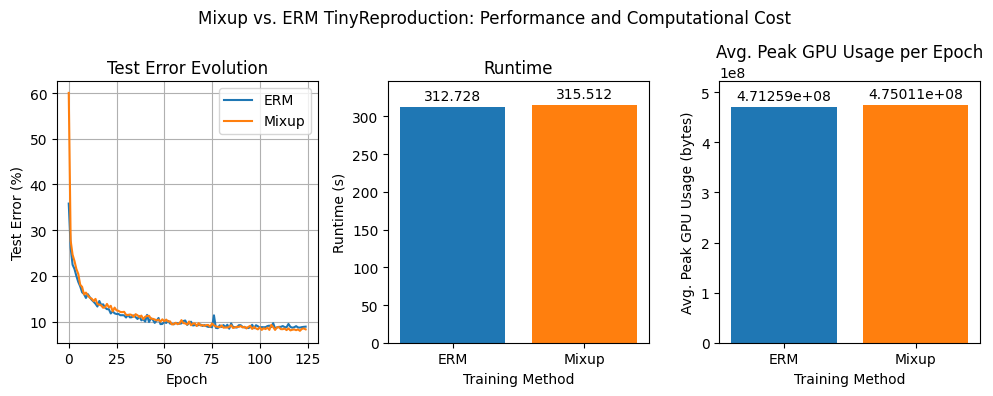

In [9]:
#RECOMMEND RUNNING ONE AT A TIME, COMMENT OTHERS OUT
#Standard ERM vs. Mixup
epochs = 125
[train_accs, test_accs, max_gpu, train_accs_mixup, test_accs_mixup,
 max_gpu_mixup, elapsed, elapsed_mixup] = runscript(0.4, train_batch,
                                                                test_batch, epochs)

plotting(train_accs, test_accs, max_gpu, train_accs_mixup, test_accs_mixup,
         max_gpu_mixup, elapsed, elapsed_mixup, epochs)

#TEST FOR CORRUPTED LABELS

# #Corrupt labels at 20% rate
# [train_20, real_20] = corrupt_labels(copy.deepcopy(train_in), 0.2)
# train_batch_20 = torch.utils.data.DataLoader(train_20, batch_size=b_size, shuffle=True)
# #Get performance comparison
# [train_accs_20, test_accs_20, max_gpu_20, train_accs_mixup_20,
#  test_accs_mixup_20, max_gpu_mixup_20, elapsed_20, elapsed_mixup_20] = runscript(8, train_batch_20, test_batch, epochs)

# plotting(train_accs_20, test_accs_20, max_gpu_20, train_accs_mixup_20,
#           test_accs_mixup_20, max_gpu_mixup_20, elapsed_20,elapsed_mixup_20, epochs, 0.2)

#  #Corrupt labels at 50% rate
# [train_50, real_50] = corrupt_labels(copy.deepcopy(train_in), 0.5)
# train_batch_50 = torch.utils.data.DataLoader(train_50, batch_size=b_size, shuffle=True)
# #Get performance comparison
# [train_accs_50, test_accs_50, max_gpu_50, train_accs_mixup_50,
#  test_accs_mixup_50, max_gpu_mixup_50, elapsed_50, elapsed_mixup_50] = runscript(32, train_batch_50, test_batch, epochs)

# plotting(train_accs_50, test_accs_50, max_gpu_50, train_accs_mixup_50,
#  test_accs_mixup_50, max_gpu_mixup_50, elapsed_50, elapsed_mixup_50, epochs, 0.5)

# # #Corrupt labels at 80% rate
# [train_80, real_80] = corrupt_labels(copy.deepcopy(train_in), 0.8)
# train_batch_80 = torch.utils.data.DataLoader(train_80, batch_size=b_size, shuffle=True)
# #Get performance comparison
# [train_accs_80, test_accs_80, max_gpu_80, train_accs_mixup_80,
#  test_accs_mixup_80, max_gpu_mixup_80, elapsed_80, elapsed_mixup_80] = runscript(32, train_batch_80, test_batch, epochs)

# plotting(train_accs_80, test_accs_80, max_gpu_80, train_accs_mixup_80,
#  test_accs_mixup_80, max_gpu_mixup_80, elapsed_80, elapsed_mixup_80, epochs, 0.8)


#TEST FOR ADVERSARIAL ATTACKS
# [train_accs_adv, test_accs_adv, max_gpu_adv, train_accs_mixup_adv,
#  test_accs_mixup_adv, max_gpu_mixup_adv, elapsed_adv, elapsed_mixup_adv] = runscript(1, train_batch, test_batch, epochs,adv=True)

# plotting(train_accs_adv, test_accs_adv, max_gpu_adv, train_accs_mixup_adv, test_accs_mixup_adv,
#          max_gpu_mixup_adv, elapsed_adv, elapsed_mixup_adv, epochs, adv=True)